# Velocity reprojection
Point-to-point reprojection for velocity

In [2]:
import os
import numpy as np
import pandas as pd
from pyproj import Transformer, CRS, Geod
from shapely.geometry import Point
import rasterio
from rasterio.warp import Resampling, calculate_default_transform
from rasterio.features import rasterize

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import TwoSlopeNorm

from raster_basics.RasterBasics import tifReprojectionResample, rasterLike


Velocity reprojection function

In [3]:
def fillArrayHoles(arr, fillmask, dist=10, iters=1):
    '''
    Fill hole in array
    	arr: array to fill holes (np array)
     	fillmask: mask where to fill holes. hole-filling applied where mask=0 (np array)
      	dist: the maximum number of pixels to search in all directions to find values to interpolate from (int)
        iters: the number of 3x3 smoothing filter passes to run (int)
    '''
    # use rasterio fill fillnodata to fill holes in our array
    inputFilled = rasterio.fill.fillnodata(arr, mask=fillmask, max_search_distance=dist, smoothing_iterations=iters)
    inputFilled[pd.isnull(inputFilled) == True] = 0
    return inputFilled


def fillHole(file, dest='output_filled.tif', dist=10, iters=1, mask=None):
    """
    Fill hole in raster
	file: input raster to fill (str) (e.g. 'input.tif')
	dest: output filename (str) (e.g. 'output_raster.tif')
	dist: the maximum number of pixels to search in all directions to find values to interpolate from (int)
	iters: the number of 3x3 smoothing filter passes to run (int)
    """
    with rasterio.open(file) as src:
        profile = src.profile
        inputs = src.read(1)

        if mask == None:
            fillmask = inputs.copy() # fillnodata is applied where the mask=0
            fillmask[inputs>=0] = 1
            fillmask[fillmask!=1] = 0
        else:
            fillmask = mask.copy()

        filledRaster = fillArrayHoles(inputs, fillmask=fillmask, dist=dist, iters=iters)

    with rasterio.open(dest, 'w', **profile) as dst:
        dst.write_band(1, filledRaster)

In [4]:
def reproject_velocity(vx_fp, vy_fp, from_epsg, to_epsg, output_vx_fp, output_vy_fp, nan_val=np.nan, apply_correction=False, plot_changes=False, **kwargs):
    '''
    Reproject velocity:
        1. Extract velocity data from geotiff
        2. Convert geotiff to points: get start and end point of velocity vector
        3. Reproject start and end points to new coordinate system
        4. Rasterize reprojected points in new coordinate system
        5. OPTIONAL: apply_correction: Adjust velocity vectors based on magnitude of a direct reprojection
        6. OPTIONAL: plot_changes: Plot velocity vector reproject (contains optional arguments for plotting)

    Arguments:
        vx_fp, vy_fp: Input velocity vectors
        from_epsg, to_epsg: Initial and target coordinate systems in EPSG number (e.g., 32606)
        output_vx_fp, output_vy_fp: Output filepaths
        nan_val: data NaN value to remove (default: np.nan. NOTE: absolute values greater than 1e30 are automatically removed from data)
        apply_correction: whether to apply a correction that matches velocity magnitude with the direct reprojection (default: False)
        plot_changes: show plot of reprojection (default: False)
        **kwargs: Optional arguments passed along for plotting (quiv_scale, quiv_width, title, ctitle, base_arr_color, vmin, vcenter, vmax) 
    '''
        
    # ----------------  1. extract velocity data from existing geotiff ---------------- 
    proj_from = CRS.from_user_input(from_epsg)
    proj_to = CRS.from_user_input(to_epsg)
    with rasterio.open(vx_fp) as vx_src, rasterio.open(vy_fp) as vy_src:
        vx_data = vx_src.read(1)  # Read the vx component
        vy_data = vy_src.read(1)  # Read the vy component
        v_res = vx_src.res
        v_bounds = vx_src.bounds
        transform_from = vx_src.transform  # Get the affine transform of the original raster
        
    # ---------------- 2. convert geotiff values to points ---------------- 
    rows, cols = np.indices(vx_data.shape)
    lon, lat = rasterio.transform.xy(transform_from, rows, cols)
    points_from = np.column_stack((np.array(lon).flatten(), np.array(lat).flatten()))

    # calculate the velocity endpoints
    vx_data[np.abs(vx_data) > 1e30] = 0 # remove unrealistic values
    vy_data[np.abs(vy_data) > 1e30] = 0
    if np.isnan(nan_val): # remove NaN values
        vx_data[np.isnan(vx_data)] = 0
        vy_data[np.isnan(vy_data)] = 0
    else:
        vx_data[vx_data == nan_val] = 0
        vy_data[vy_data == nan_val] = 0
    vv_data = (vx_data**2 + vy_data**2)**0.5

    if proj_from.is_geographic:
        earth_radius = 6378137.0  # WGS84 semi-major axis, meters
        lat_rad = np.deg2rad(points_from[:, 1])
        meters_per_deg_lat = (np.pi / 180.0) * earth_radius
        meters_per_deg_lon = meters_per_deg_lat * np.cos(lat_rad)
        # avoid division by zero at the poles (not expected for glacier data, but safe)
        meters_per_deg_lon = np.where(np.abs(meters_per_deg_lon) < 1e-9, np.nan, meters_per_deg_lon)
        dlon = vx_data.flatten() / meters_per_deg_lon
        dlat = vy_data.flatten() / meters_per_deg_lat
        endpoints_from = np.column_stack((points_from[:,0] + dlon, points_from[:,1] + dlat))
    else:
        endpoints_from = np.column_stack((points_from[:,0] + vx_data.flatten(), points_from[:,1] + vy_data.flatten()))

    # ---------------- 3. reproject start and end points ---------------- 
    transformer = Transformer.from_crs(proj_from, proj_to, always_xy=True)
    points_to = np.array([transformer.transform(x, y) for x, y in points_from])
    endpoints_to = np.array([transformer.transform(x, y) for x, y in endpoints_from])

    raw_dx = endpoints_to[:,0] - points_to[:,0]
    raw_dy = endpoints_to[:,1] - points_to[:,1]
    vv = np.sqrt(raw_dx**2 + raw_dy**2)
    azimuth_rad = np.arctan2(raw_dx, raw_dy)  # 0=North(+y), clockwise positive
    dx = vv * np.sin(azimuth_rad)
    dy = vv * np.cos(azimuth_rad)

    angles = np.arctan2(dy, dx)
    mask = ~((np.isnan(dx) | (dx == 0)) & (np.isnan(dy) | (dy == 0))) # mask off-glacier
    
    # ---------------- 4. rasterize points ----------------     
    # Use calculate_default_transform to get a CRS-appropriate transform/width/height
    # for the TARGET projection (handles degree <-> meter unit changes correctly,
    # rather than reusing the source pixel size/shape, which is meaningless once
    # the units of the coordinate system have changed).
    transform_to, width, height = calculate_default_transform(
        proj_from, proj_to, vx_data.shape[1], vx_data.shape[0],
        *v_bounds, resolution=None
    )

    # prepare the data for rasterization
    points_vx = [(Point(coord), value) for coord, value in zip(zip(points_to[:,0][mask], points_to[:,1][mask]), dx[mask])]
    points_vy = [(Point(coord), value) for coord, value in zip(zip(points_to[:,0][mask], points_to[:,1][mask]), dy[mask])]

    # rasterize the data using the target-CRS transform/shape computed above
    vx_arr = rasterize(points_vx, out_shape=(height, width), transform=transform_to, dtype='float32')
    vy_arr = rasterize(points_vy, out_shape=(height, width), transform=transform_to, dtype='float32')
    vv_arr = np.sqrt(vx_arr**2 + vy_arr**2)

    with rasterio.open(output_vx_fp, 'w', driver='GTiff', height=height, width=width, count=1, dtype='float32', 
                       crs=proj_to, transform=transform_to) as dst:
        dst.write(vx_arr, 1)
    with rasterio.open(output_vy_fp, 'w', driver='GTiff', height=height, width=width, count=1, dtype='float32', 
                       crs=proj_to, transform=transform_to) as dst:
        dst.write(vy_arr, 1)

    # ------------------- plotting ----------------------
    if plot_changes:
        quiv_scale = kwargs.get('quiv_scale', 200)
        quiv_width = kwargs.get('quiv_width', 0.005)
        quiv_color= kwargs.get('quiv_color', 'autumn')
    
        title = kwargs.get('title', '')
        ctitle = kwargs.get('ctitle', '')
        base_arr_color = kwargs.get('base_arr_color', 'BrBG')
        base_arr_vmin = kwargs.get('base_arr_vmin', 0)
        base_arr_vcenter = kwargs.get('base_arr_vcenter', 10)
        base_arr_vmax = kwargs.get('base_arr_vmax', 50)
    
        # original plot
        rasterLike(vv_data, 'tmp_vv_plt.tif', vx_fp)
        quiv_plot(points_from[:,0], points_from[:,1], vx_data.flatten(), vy_data.flatten(), vv_data.flatten(), quiv_scale,
                  quiv_width=quiv_width, quiv_color=quiv_color,
                  base_tiff='tmp_vv_plt.tif', title=f'{title} vv_init', ctitle=ctitle, base_arr_color=base_arr_color,  
                  base_arr_vmin=base_arr_vmin, base_arr_vcenter=base_arr_vcenter, base_arr_vmax=base_arr_vmax)

        # reprojected plot
        rasterLike(vv_arr, 'tmp_vv_plt.tif', output_vx_fp)
        quiv_plot(points_to[:,0][mask], points_to[:,1][mask], dx[mask], dy[mask], vv[mask], quiv_scale,
                  quiv_width=quiv_width, quiv_color=quiv_color, base_tiff='tmp_vv_plt.tif', title=f'{title} vv_reproj', 
                  ctitle=ctitle, base_arr_color=base_arr_color, base_arr_vmin=base_arr_vmin, 
                  base_arr_vcenter=base_arr_vcenter, base_arr_vmax=base_arr_vmax)

    # ---------------- 5. apply correction based on straight reprojection magnitude ----------------
    if apply_correction:
        # target-CRS pixel size, derived from the transform calculate_default_transform
        # produced above -- NOT the source pixel size (v_res), which is in the wrong
        # units whenever from_epsg/to_epsg differ between degrees and meters.
        pixel_size_x = transform_to.a
        pixel_size_y = -transform_to.e  # transform.e is negative (north-up convention)
        rel_diff = np.abs(pixel_size_x - pixel_size_y) / max(np.abs(pixel_size_x), np.abs(pixel_size_y))
        assert rel_diff < 0.01, f'Pixels are not square: ({pixel_size_x:.6f}, {pixel_size_y:.6f})'

        # straight reprojection of velocity data, using the target-CRS pixel size
        tifReprojectionResample(vx_fp, 'temp_vx.tif', proj_to, pixel_size_x, Resampling.cubic_spline) # reproject
        tifReprojectionResample(vy_fp, 'temp_vy.tif', proj_to, pixel_size_x, Resampling.cubic_spline)
        vx_arr_tmp = rasterio.open('temp_vx.tif').read(1)
        vy_arr_tmp = rasterio.open('temp_vy.tif').read(1)
        vx_arr_tmp[(np.abs(vx_arr_tmp) >= 1e10) | np.isnan(vx_arr_tmp)] = 0
        vy_arr_tmp[(np.abs(vy_arr_tmp) >= 1e10) | np.isnan(vy_arr_tmp)] = 0

        # tifReprojectionResample resamples the ORIGINAL vx/vy values (still in the
        # source CRS's linear units, e.g. meters) onto the target grid -- it does not
        # reinterpret them as degrees, so no unit conversion is needed here even when
        # proj_to is geographic. vv_dir_arr is therefore already in the same physical
        # units (meters) as vv_arr/vx_arr/vy_arr above.
        vv_dir_arr = (vx_arr_tmp**2 + vy_arr_tmp**2)**0.5 # derive velocity magnitude 

        # adjust point-to-point velocity based on magnitude
        mask_mag = (vv_dir_arr != 0) & (vv_arr != 0)
        vx_arr_corr = np.copy(vx_arr)
        vy_arr_corr = np.copy(vy_arr)
        vx_arr_corr[mask_mag] = vx_arr[mask_mag] * vv_dir_arr[mask_mag] / vv_arr[mask_mag]
        vy_arr_corr[mask_mag] = vy_arr[mask_mag] * vv_dir_arr[mask_mag] / vv_arr[mask_mag]
        rasterLike(vx_arr_corr, output_vx_fp, 'temp_vx.tif')
        rasterLike(vy_arr_corr, output_vy_fp, 'temp_vy.tif')
        os.remove('temp_vx.tif')
        os.remove('temp_vy.tif')
        
    # ------------------- plotting ----------------------
    if plot_changes:
        # reprojected plot, with correction
        if apply_correction:
            vv_arr_corr = np.sqrt(vx_arr_corr**2 + vy_arr_corr**2)
            rasterLike(vv_arr_corr, 'tmp_vv_plt.tif', output_vx_fp)
            quiv_plot(points_to[:,0][mask], points_to[:,1][mask], dx[mask], dy[mask], vv[mask], quiv_scale,
                      quiv_width=quiv_width, quiv_color=quiv_color, base_tiff='tmp_vv_plt.tif', title=f'{title} vv_corr', 
                      ctitle=ctitle, base_arr_color=base_arr_color, base_arr_vmin=base_arr_vmin, 
                      base_arr_vcenter=base_arr_vcenter, base_arr_vmax=base_arr_vmax)
        
        os.remove('tmp_vv_plt.tif')
        

In [5]:
def quiv_plot(q1, q2, q3, q4, q5, q6, base_tiff=None, **kwargs):
    """
    Plots a velocity field with arrows and an optional background array.
    
    Parameters:
        q1, q2, q3, q4: Coordinates and components for quiver plot.
        q5: Magnitude of arrows for quiver.
        q6: Scale factor for quiver arrows.
        base_tiff: Geotiff for the background plot (optional).
        **kwargs: Additional parameters for base array customization:
            - `quiv_width`: Quiver arrow width
            - `quiv_color`: Quiver arrow color
            - `title`: Plot title
            - `ctitle`: Colorbar title
            - `base_arr_color`: Colormap for the base array (default is 'RdBu').
            - `base_arr_ext`: Extent of the base array (default is None).
            - `base_arr_vmin`, `base_arr_vcenter`, `base_arr_vmax`: Min, center, and max for colorbar (default is -50, 0, 50)
    """    
    fig = plt.figure()
    ax = fig.add_subplot(111)  
    
    quiv_width = kwargs.get('quiv_width', 0.005)
    quiv_color= kwargs.get('quiv_color', 'autumn')
    ax.quiver(q1, q2, q3, q4, q5, cmap=quiv_color, scale=q6, width=quiv_width)

    title = kwargs.get('title', None)
    ctitle = kwargs.get('ctitle', None)
    base_arr_color = kwargs.get('base_arr_color', 'RdBu')
    base_arr_vmin = kwargs.get('base_arr_vmin', 0)
    base_arr_vcenter = kwargs.get('base_arr_vcenter', 10)
    base_arr_vmax = kwargs.get('base_arr_vmax', 50)
    if base_tiff is not None:
        divnorm = TwoSlopeNorm(vmin=base_arr_vmin, vcenter=base_arr_vcenter, vmax=base_arr_vmax)
        base_ext = [rasterio.open(base_tiff).bounds[0], rasterio.open(base_tiff).bounds[2], 
                    rasterio.open(base_tiff).bounds[1], rasterio.open(base_tiff).bounds[3]]
        im = ax.imshow(rasterio.open(base_tiff).read(1), cmap=mpl.colormaps[base_arr_color], norm=divnorm, extent=base_ext)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(im, cax=cax, label=ctitle)
    
    ax.set_title(title, weight='bold', pad=10)
    fig.tight_layout(pad=3, w_pad=-3.0, h_pad=2.0)
    plt.show()
    

Load velocity data

In [6]:
# coordinate system and resolution
crs = 2056  # UTM zone 6N # epsg 2056
res = 25 # output pixel resolution (m)


In [7]:
# locate velocity data
vx_fp_init = '/Users/albwel/Downloads/Aletsch_vels/aletsch_vx_EPSG4326.tif'
vy_fp_init = '/Users/albwel/Downloads/Aletsch_vels/aletsch_vy_EPSG4326.tif'

# point-to-point reprojection (save files)
vx_fp_ptp = 'Aletsch_vels/vx_reproj_ptp.tif' 
vy_fp_ptp = 'Aletsch_vels/vy_reproj_ptp.tif'
vv_fp_ptp = 'Aletsch_vels/vv_reproj_ptp.tif'


In [8]:
# check data CRS
crs_init = int(str(rasterio.open(vx_fp_init).crs).split(':')[1])
crs_init


4326

Point-point reprojection

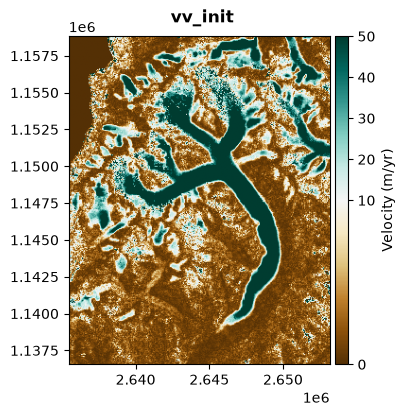

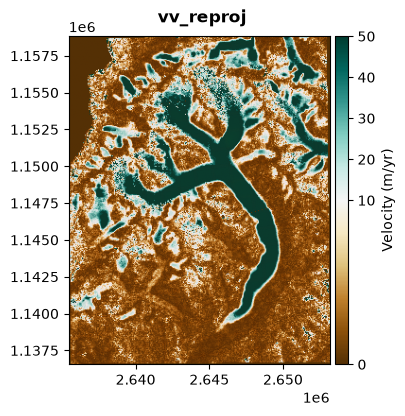

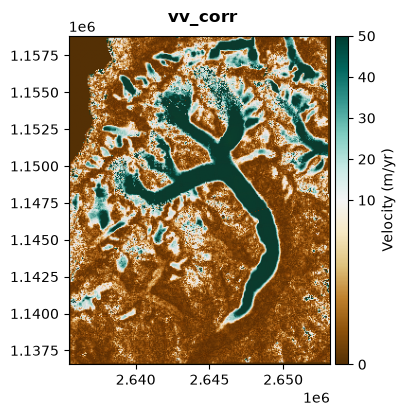

In [9]:
# fill holes
fillHole(vx_fp_init, dest=vx_fp_ptp, dist=0.0005, iters=1, mask=None) # dist in degrees (0.0001 ~= 11 m)
fillHole(vy_fp_init, dest=vy_fp_ptp, dist=0.0005, iters=1, mask=None)

# reproject
reproject_velocity(vx_fp=vx_fp_ptp, vy_fp=vy_fp_ptp, from_epsg=crs_init, to_epsg=crs,
                   output_vx_fp=vx_fp_ptp, output_vy_fp=vy_fp_ptp, 
                   apply_correction=True, plot_changes=True,
                   quiv_scale=1e6, 
                   quiv_width=0.001, 
                   ctitle='Velocity (m/yr)', vmin=0)


In [10]:
tifReprojectionResample(vx_fp_ptp, vx_fp_ptp, crs, res, Resampling.cubic_spline)
tifReprojectionResample(vy_fp_ptp, vy_fp_ptp, crs, res, Resampling.cubic_spline)


### Compare velocity reprojection

In [11]:
def quiv(vx, vy, v_tot, pixel_size, threshold):
    freq = pixel_size
    xx = np.arange(0, vx.shape[1], freq)                          # last number represents arrow frequency
    yy = np.arange(0, vy.shape[0], freq)
    points = np.ix_(yy, xx)
    px, py = np.meshgrid(xx, yy)
    
    vx_norm = np.divide(vx[points], v_tot[points], out=np.zeros_like(vx[points]), where=v_tot[points] > threshold)
    vy_norm = np.divide(vy[points], v_tot[points], out=np.zeros_like(vx[points]), where=v_tot[points] > threshold)
    vx_norm[np.isnan(vx_norm)] = 0
    vy_norm[np.isnan(vy_norm)] = 0
    
    mask = np.logical_or(vx_norm != 0, vy_norm != 0)                # remove 0 points
    quiverInput = [px[mask], py[mask], vx_norm[mask], vy_norm[mask], 1, 'gist_gray', 20]
    return quiverInput


In [14]:
# get the quiver velocity arrow inputs
vv_arr_ptp = (rasterio.open(vx_fp_ptp).read(1)**2 + rasterio.open(vy_fp_ptp).read(1)**2)**0.5
quiver_ptp = quiv(rasterio.open(vx_fp_ptp).read(1), rasterio.open(vy_fp_ptp).read(1), vv_arr_ptp, 20, threshold=5)


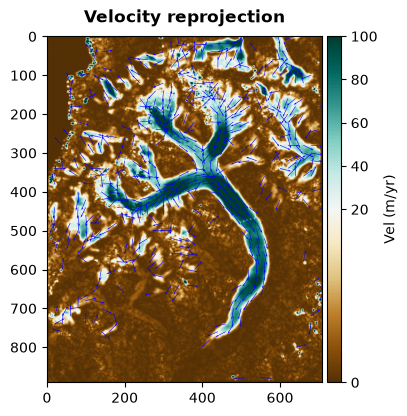

In [15]:
q_color_ptp = 'winter' # arrow color
color = 'BrBG' # plot color

fig = plt.figure()
ax = fig.add_subplot(111, label="1")

divnorm = TwoSlopeNorm(vmin=0, vcenter=20, vmax=100)
im = ax.imshow(vv_arr_ptp, cmap=color, norm=divnorm)

ax.quiver(quiver_ptp[0], quiver_ptp[1], quiver_ptp[2], quiver_ptp[3], quiver_ptp[4], cmap=q_color_ptp, 
          scale=quiver_ptp[6]*1.2, width=.002)
divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, label='Vel (m/yr)')
ax.set_title('Velocity reprojection', weight='bold', pad=10)
fig.tight_layout(pad=3, w_pad=-3.0, h_pad=2.0)
plt.show()
    